In [32]:
!git clone https://github.com/MilanBojic1999/RAF-PetFinder-dataset.git

fatal: destination path 'RAF-PetFinder-dataset' already exists and is not an empty directory.


In [33]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np

Ucitavanje podataka

In [34]:
dir = "RAF-PetFinder-dataset/Data"

train_df = pd.read_csv(f"{dir}/train.csv")
train_sentiment_df = pd.read_csv(f"{dir}/train_sentiment.csv")

print("Train:", train_df.shape)
print("Train sentiment:", train_sentiment_df.shape)

Train: (14993, 24)
Train sentiment: (14442, 3)


Merge sentiment podataka

In [35]:
train_df = train_df.merge(train_sentiment_df, on="PetID", how="left")
print("After merge:", train_df.shape)

After merge: (14993, 26)


Drop suvisnih kolona

In [36]:
train_df = train_df.drop(columns=["Name", "State", "RescuerID", "VideoAmt"], axis=1)

Split trening skupa

In [37]:
train, tmp_split = train_test_split(
    train_df,
    test_size=0.20,
    stratify=train_df["AdoptionSpeed"],
    random_state=10723
)


val, test = train_test_split(
    tmp_split,
    test_size=0.50,
    stratify=tmp_split["AdoptionSpeed"],
    random_state=10723
)

print("Train:", len(train))
print("Val:", len(val))
print("Test:", len(test))

Train: 11994
Val: 1499
Test: 1500


In [38]:
train.to_csv("train.csv", index=False)
val.to_csv("val.csv", index=False)
test.to_csv("test.csv", index=False)

Ucitavanje slika

In [39]:
image_dir = f"{dir}/train_images"

pet_ids = set(train["PetID"].astype(str))

n = 3
pet_images = {}

for filename in os.listdir(image_dir):
    pet_id = filename.split('-')[0]
    if pet_id in pet_ids:
        if pet_id not in pet_images:
            pet_images[pet_id] = []
        if len(pet_images[pet_id]) < n:
            full_path = os.path.join(image_dir, filename)
            pet_images[pet_id].append(full_path)
print(len(pet_images), "images found")

11729 images found


Analiza podataka

In [40]:
df = pd.read_csv('train.csv')
df.head()

,Type,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,...,Sterilized,Health,Quantity,Fee,Description,PetID,PhotoAmt,AdoptionSpeed,SentimentScore,SentimentMagnitude
0,1,4,141,307,2,1,0,0,2,1,...,3,1,2,0,Ebony and Whisper are cute little abandoned pu...,bd56db16a,5.0,3,0.8,0.8
1,2,3,266,264,3,1,6,7,3,2,...,2,1,4,0,My girl Anjo just give birth to 4 cute little ...,6dbc5c968,9.0,3,0.1,0.4
2,1,84,205,0,1,5,7,0,1,2,...,3,2,1,0,He was abandoned in market by irresponsible ow...,bfdd20655,2.0,2,-0.1,2.0
3,2,5,266,0,2,1,2,7,1,1,...,1,1,1,0,"Adopters must vaccinate,and keep kitten indoor...",556599752,3.0,3,0.1,0.7
4,1,12,307,0,1,2,7,0,2,1,...,2,1,1,0,Spike is a loving boy that is looking for a lo...,bc8aedde4,3.0,4,0.7,2.2


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11994 entries, 0 to 11993
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Type                11994 non-null  int64  
 1   Age                 11994 non-null  int64  
 2   Breed1              11994 non-null  int64  
 3   Breed2              11994 non-null  int64  
 4   Gender              11994 non-null  int64  
 5   Color1              11994 non-null  int64  
 6   Color2              11994 non-null  int64  
 7   Color3              11994 non-null  int64  
 8   MaturitySize        11994 non-null  int64  
 9   FurLength           11994 non-null  int64  
 10  Vaccinated          11994 non-null  int64  
 11  Dewormed            11994 non-null  int64  
 12  Sterilized          11994 non-null  int64  
 13  Health              11994 non-null  int64  
 14  Quantity            11994 non-null  int64  
 15  Fee                 11994 non-null  int64  
 16  Desc

In [42]:
df.isnull().sum()

,0
Type,0
Age,0
Breed1,0
Breed2,0
Gender,0
Color1,0
Color2,0
Color3,0
MaturitySize,0
FurLength,0


In [43]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Type,11994.0,1.456311,0.498108,1.0,1.0,1.0,2.0,2.0
Age,11994.0,10.409121,18.003473,0.0,2.0,3.0,12.0,255.0
Breed1,11994.0,265.157829,60.255124,0.0,265.0,266.0,307.0,307.0
Breed2,11994.0,74.467734,123.352245,0.0,0.0,0.0,189.0,307.0
Gender,11994.0,1.777639,0.679288,1.0,1.0,2.0,2.0,3.0
Color1,11994.0,2.239953,1.751592,1.0,1.0,2.0,3.0,7.0
Color2,11994.0,3.214524,2.745660,0.0,0.0,2.0,6.0,7.0
Color3,11994.0,1.882441,2.982847,0.0,0.0,0.0,5.0,7.0
MaturitySize,11994.0,1.858929,0.545848,1.0,2.0,2.0,2.0,4.0
FurLength,11994.0,1.469401,0.598733,1.0,1.0,1.0,2.0,3.0


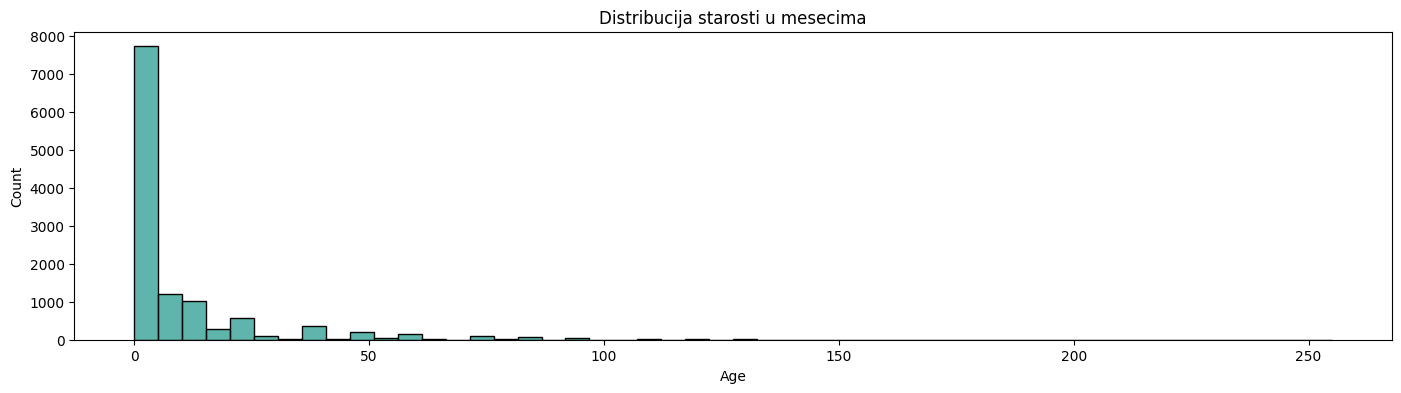

In [44]:
plt.figure(figsize=(17,4))
sns.histplot(df['Age'], bins=50, color='#2A9D8F')
plt.title('Distribucija starosti u mesecima')
plt.show()

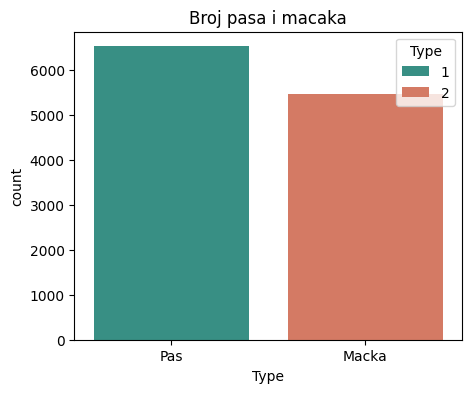

In [45]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Type', hue='Type',  palette=['#2A9D8F', '#E76F51'])
plt.title('Broj pasa i macaka')
plt.xticks([0,1], ['Pas', 'Macka'])
plt.show()

Text(0.5, 1.0, 'Adoption speed by Age and Type')

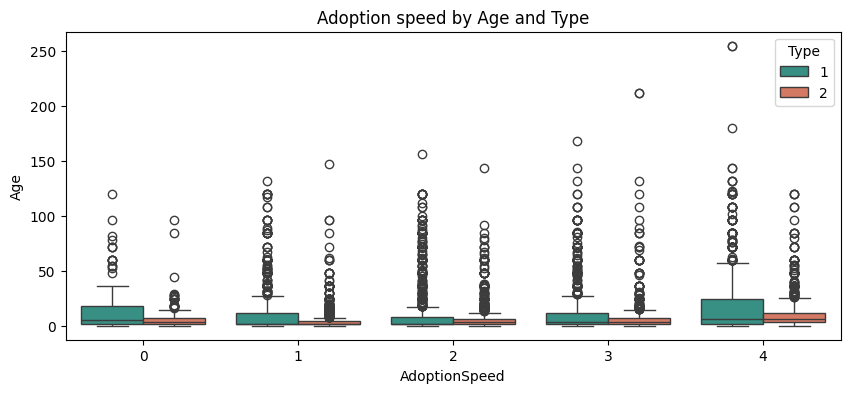

In [46]:
plt.figure(figsize=(10, 4));
sns.boxplot(data=df, x='AdoptionSpeed', y = 'Age', hue = 'Type', palette=['#2A9D8F', '#E76F51']);
plt.title('Adoption speed by Age and Type')

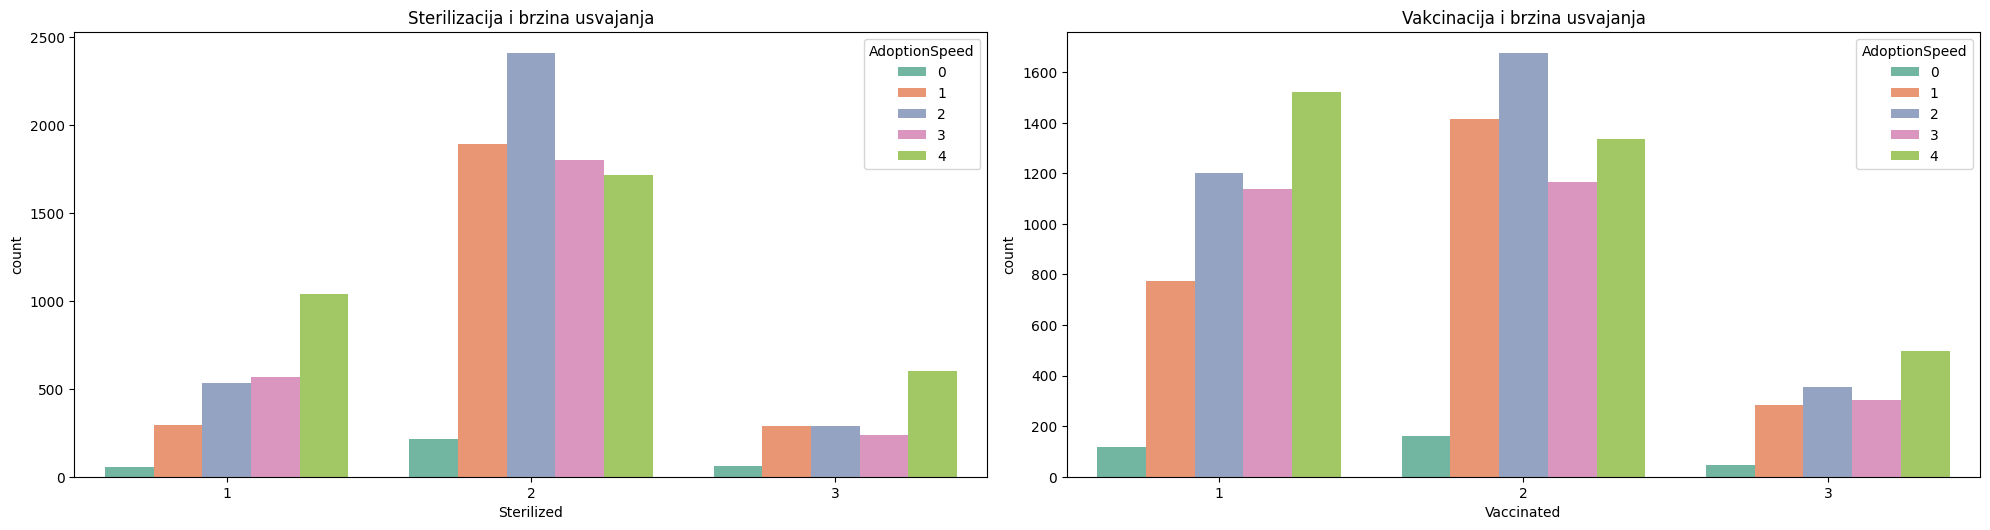

In [47]:
plt.figure(figsize=(20, 10))

plt.subplot(2, 2, 1)
sns.countplot(data=df, x='Sterilized', hue='AdoptionSpeed', palette='Set2')
plt.title('Sterilizacija i brzina usvajanja')

plt.subplot(2, 2, 2)
sns.countplot(data=df, x='Vaccinated', hue='AdoptionSpeed',  palette='Set2')
plt.title('Vakcinacija i brzina usvajanja')

plt.tight_layout()
plt.show()

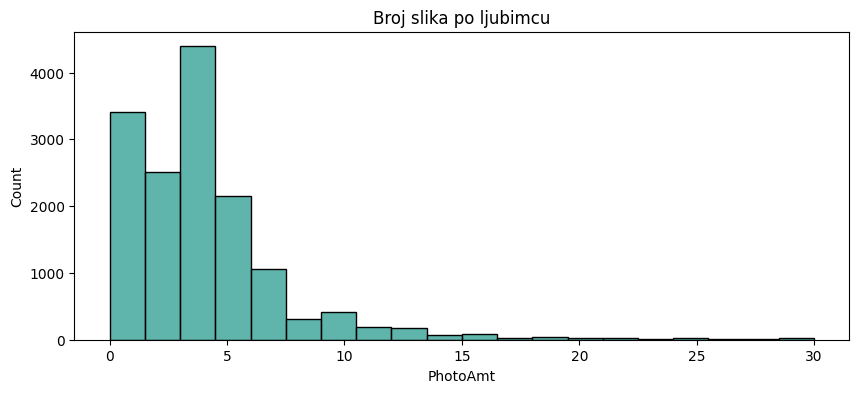

In [48]:
plt.figure(figsize=(10,4))
sns.histplot(train_df['PhotoAmt'], bins=20, color='#2A9D8F')
plt.title('Broj slika po ljubimcu')
plt.show()

Text(0.5, 1.0, 'Quantity and Fee')

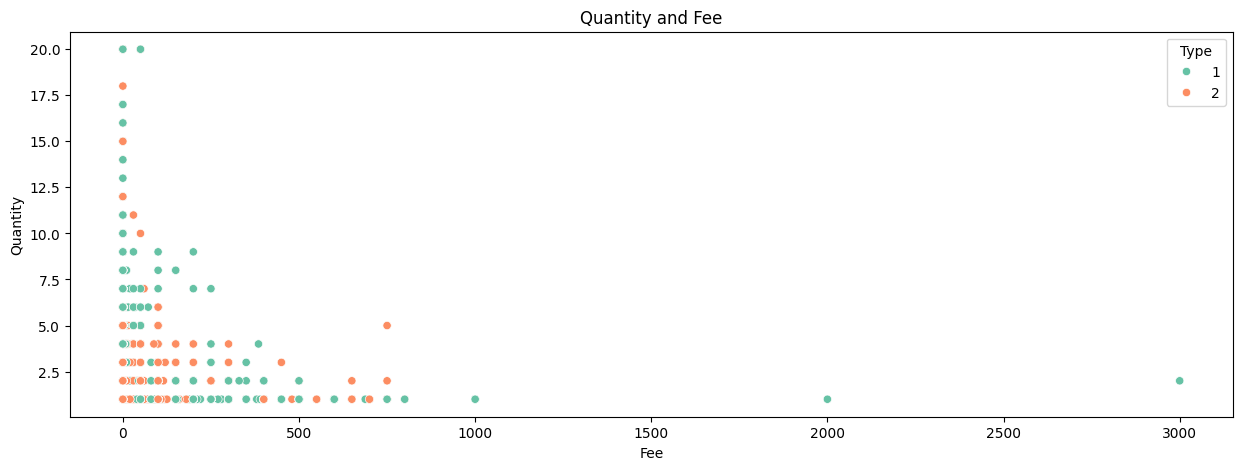

In [49]:
plt.figure(figsize=(15, 5));
sns.scatterplot(x='Fee', y= 'Quantity', hue='Type', data=df, palette="Set2");
plt.title('Quantity and Fee')

Text(0.5, 1.0, 'Adoption Speed by Type and Photo Amount')

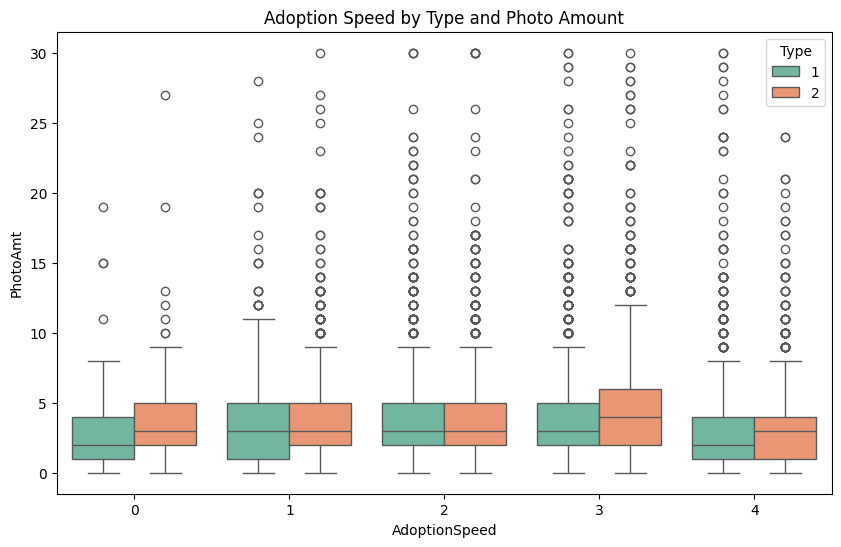

In [50]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="AdoptionSpeed", y="PhotoAmt", hue="Type", data=df, palette="Set2")
plt.title('Adoption Speed by Type and Photo Amount')

In [51]:
col = ['Age', 'Quantity', 'Fee', 'PhotoAmt', 'Health']

means = df[col].mean()
variances = df[col].var()

print("Srednje vrednosti po kolonama:")
print(means)

print("\nVarijanse po kolonama:")
print(variances)


Srednje vrednosti po kolonama:
Age         10.409121
Quantity     1.570285
Fee         21.461564
PhotoAmt     3.873854
Health       1.036768
dtype: float64

Varijanse po kolonama:
Age          324.125026
Quantity       2.148691
Fee         6448.691802
PhotoAmt      12.035199
Health         0.040422
dtype: float64


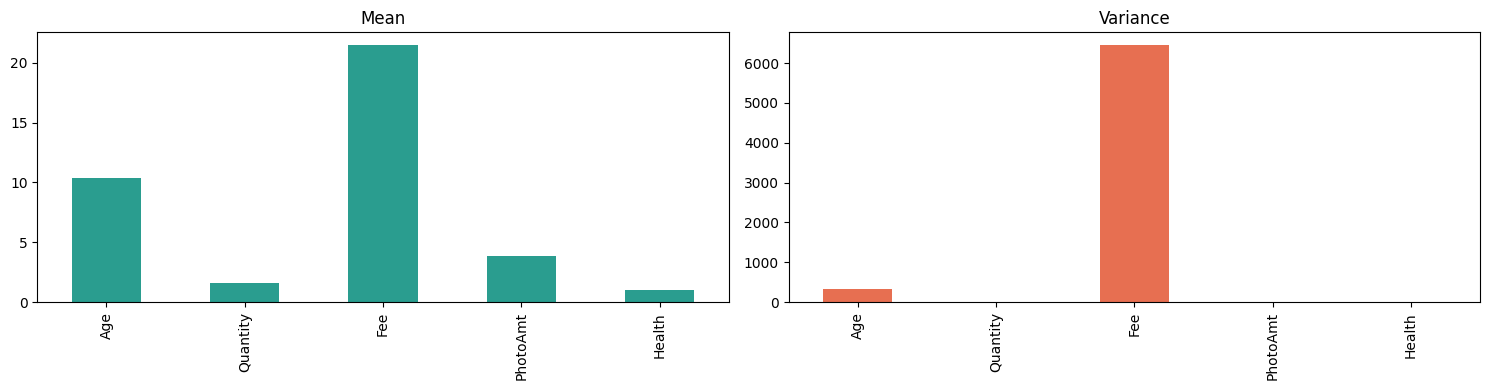

In [52]:
plt.figure(figsize=(15,4))

plt.subplot(1,2,1)
means.plot(kind='bar', color='#2A9D8F')
plt.title('Mean')

plt.subplot(1,2,2)
variances.plot(kind='bar', color='#E76F51')
plt.title('Variance')

plt.tight_layout()
plt.show()


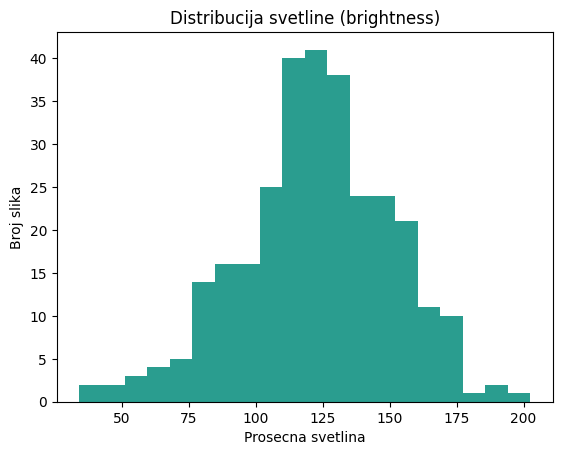

In [53]:
brightness = []

for pet_id, paths in list(pet_images.items())[:300]:
    img = Image.open(paths[0]).convert("L")
    arr = np.array(img)
    brightness.append(arr.mean())

plt.hist(brightness, bins=20, color='#2A9D8F')
plt.title("Distribucija svetline (brightness)")
plt.xlabel("Prosecna svetlina")
plt.ylabel("Broj slika")
plt.show()


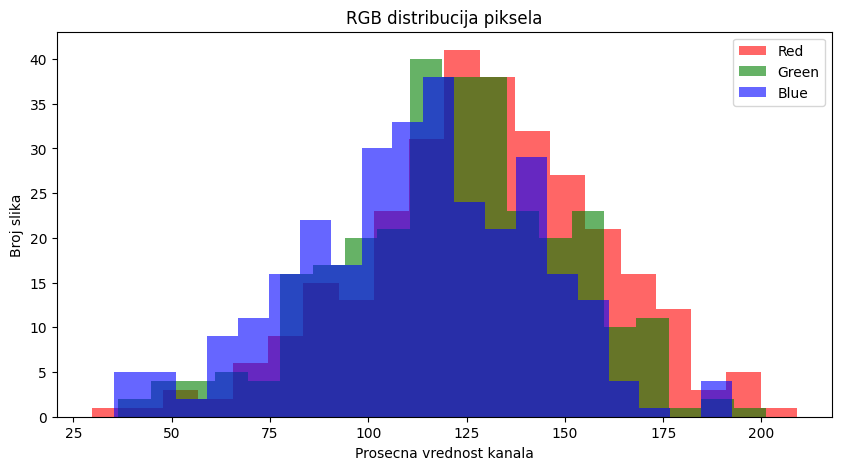

In [54]:
reds = []
greens = []
blues = []

for pet_id, paths in list(pet_images.items())[:300]:
    img = Image.open(paths[0]).convert("RGB")
    arr = np.array(img)

    reds.append(arr[:,:,0].mean())
    greens.append(arr[:,:,1].mean())
    blues.append(arr[:,:,2].mean())

plt.figure(figsize=(10,5))
plt.hist(reds, bins=20, alpha=0.6, color='red', label="Red")
plt.hist(greens, bins=20, alpha=0.6, color='green', label="Green")
plt.hist(blues, bins=20, alpha=0.6, color='blue', label="Blue")
plt.legend()
plt.title("RGB distribucija piksela")
plt.xlabel("Prosecna vrednost kanala")
plt.ylabel("Broj slika")
plt.show()
